Dataset Extracted Successfully
Dataset Path: ./extracted_dataset/Covid19-dataset
Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.

Classes:
{'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Training: CNN
Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.4263 - loss: 1.6364 - val_accuracy: 0.3030 - val_loss: 1.1363
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 779ms/step - accuracy: 0.6653 - loss: 0.7006 - val_accuracy: 0.7121 - val_loss: 0.6186
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 664ms/step - accuracy: 0.8247 - loss: 0.4455 - val_accuracy: 0.6364 - val_loss: 0.6005
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 801ms/step - accuracy: 0.9084 - loss: 0.2599 - val_accuracy: 0.8485 - val_loss: 0.3784
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 688ms/step - accuracy: 0.9124 - loss: 0.2108 - val_accuracy: 0.8485 - val_l

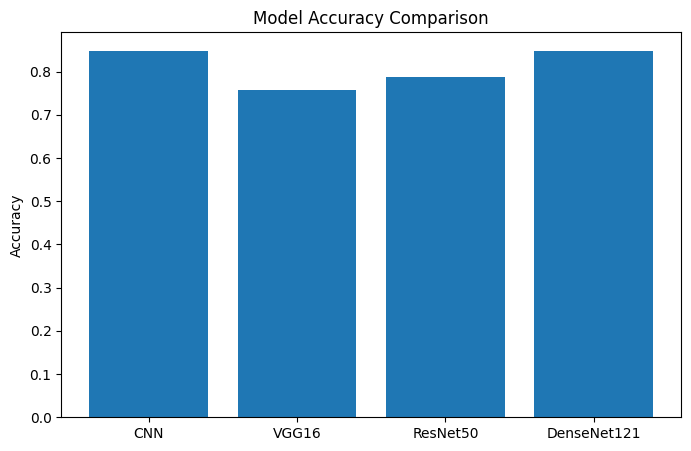

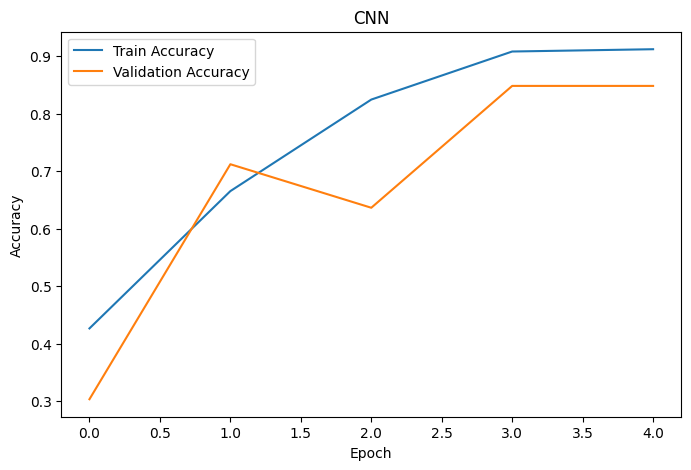

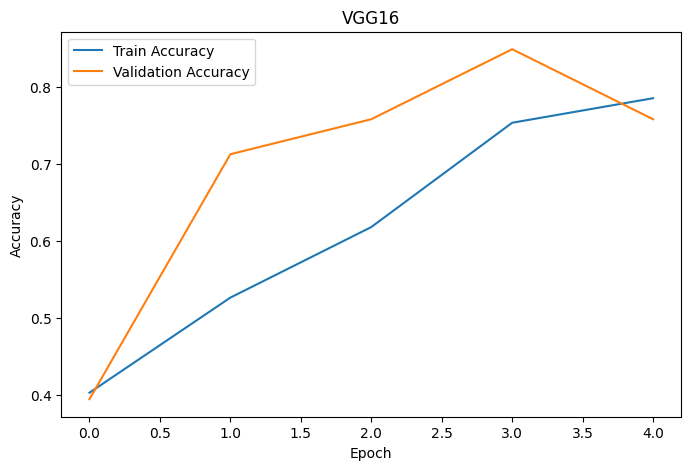

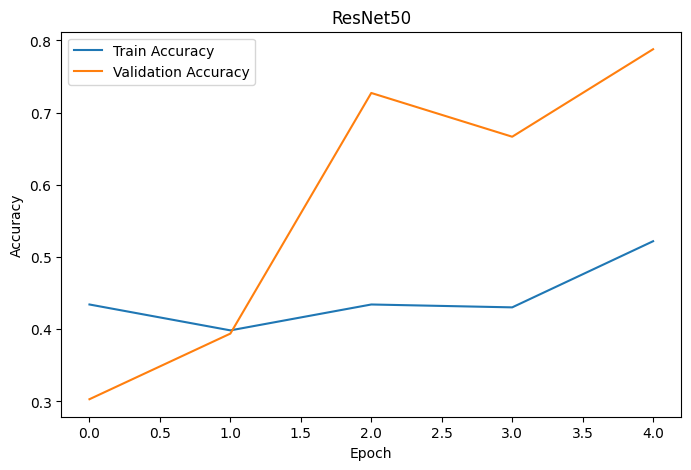

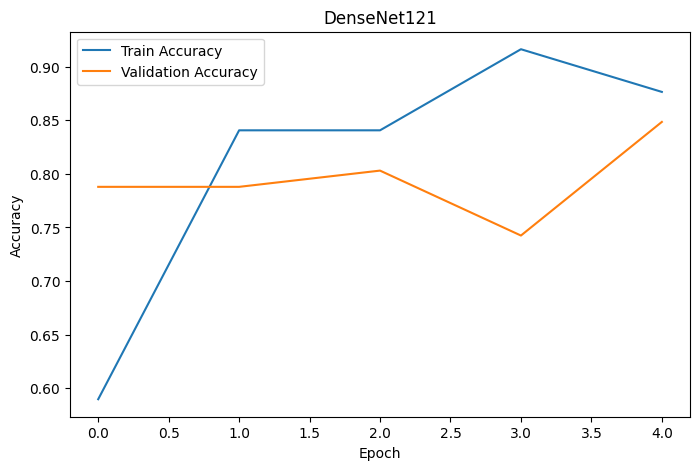


Best Model: CNN
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step


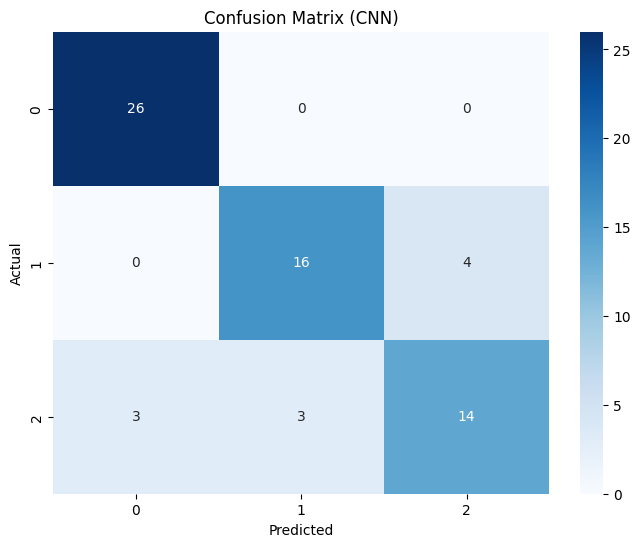

                 precision    recall  f1-score   support

          Covid       0.90      1.00      0.95        26
         Normal       0.84      0.80      0.82        20
Viral Pneumonia       0.78      0.70      0.74        20

       accuracy                           0.85        66
      macro avg       0.84      0.83      0.83        66
   weighted avg       0.84      0.85      0.84        66



In [2]:
# ==============================
# COMPLETE SINGLE-CELL PROJECT
# ==============================

import os
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import tensorflow as tf

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

from tensorflow.keras.models import Model, Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import (
    VGG16,
    ResNet50,
    DenseNet121
)

# ==========================================
# STEP 1 : EXTRACT ZIP FILE
# ==========================================

ZIP_FILE = "archive (3).zip"

EXTRACT_PATH = "./extracted_dataset/"

with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset Extracted Successfully")

# ==========================================
# STEP 2 : FIND DATASET FOLDER
# ==========================================

dataset_path = None

for root, dirs, files in os.walk(EXTRACT_PATH):
    if len(dirs) >= 2:
        dataset_path = root
        break

print("Dataset Path:", dataset_path)

# ==========================================d
# STEP 3 : IMAGE GENERATOR
# ==========================================

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5

# Create separate data generators for training and testing
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

# Check if the directories exist (optional, but good for debugging)
if not os.path.exists(train_dir):
    print(f"Error: Training directory not found at {train_dir}")
if not os.path.exists(test_dir):
    print(f"Error: Testing directory not found at {test_dir}")

train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)

print("\nClasses:")
print(train_generator.class_indices)

# ==========================================
# STEP 4 : CNN MODEL
# ==========================================

def CNN_Model():

    model = Sequential([

        Conv2D(
            32,
            (3,3),
            activation='relu',
            input_shape=(224,224,3)
        ),

        MaxPooling2D(),

        Conv2D(
            64,
            (3,3),
            activation='relu'
        ),

        MaxPooling2D(),

        Conv2D(
            128,
            (3,3),
            activation='relu'
        ),

        MaxPooling2D(),

        Flatten(),

        Dense(
            256,
            activation='relu'
        ),

        Dropout(0.5),

        Dense(
            NUM_CLASSES,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================
# STEP 5 : VGG16
# ==========================================

def VGG16_Model():

    base = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)

    x = Dense(
        256,
        activation='relu'
    )(x)

    x = Dropout(0.5)(x)

    output = Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    model = Model(
        base.input,
        output
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================
# STEP 6 : RESNET50
# ==========================================

def ResNet_Model():

    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)

    x = Dense(
        256,
        activation='relu'
    )(x)

    x = Dropout(0.5)(x)

    output = Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    model = Model(
        base.input,
        output
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================
# STEP 7 : DENSENET121
# ==========================================

def DenseNet_Model():

    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)

    x = Dense(
        256,
        activation='relu'
    )(x)

    x = Dropout(0.5)(x)

    output = Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    model = Model(
        base.input,
        output
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================
# STEP 8 : TRAIN ALL MODELS
# ==========================================

models = {
    "CNN": CNN_Model(),
    "VGG16": VGG16_Model(),
    "ResNet50": ResNet_Model(),
    "DenseNet121": DenseNet_Model()
}

histories = {}
accuracies = {}

for name, model in models.items():

    print("\n")
    print("="*50)
    print("Training:", name)
    print("="*50)

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        verbose=1
    )

    loss, acc = model.evaluate(
        val_generator,
        verbose=0
    )

    histories[name] = history
    accuracies[name] = acc

    print(name, "Accuracy:", round(acc*100,2), "%")

# ==========================================
# STEP 9 : ACCURACY COMPARISON
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    accuracies.keys(),
    accuracies.values()
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

# ==========================================
# STEP 10 : TRAINING CURVES
# ==========================================

for name, history in histories.items():

    plt.figure(figsize=(8,5))

    plt.plot(
        history.history['accuracy'],
        label='Train Accuracy'
    )

    plt.plot(
        history.history['val_accuracy'],
        label='Validation Accuracy'
    )

    plt.title(name)

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.legend()

    plt.show()

# ==========================================
# STEP 11 : BEST MODEL
# ==========================================

best_model_name = max(
    accuracies,
    key=accuracies.get
)

best_model = models[
    best_model_name
]

print("\nBest Model:", best_model_name)

# ==========================================
# STEP 12 : CONFUSION MATRIX
# ==========================================

predictions = best_model.predict(
    val_generator
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = val_generator.classes

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f'Confusion Matrix ({best_model_name})'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# ==========================================
# STEP 13 : CLASSIFICATION REPORT
# ==========================================

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(
            train_generator.class_indices.keys()
        )
    )
)

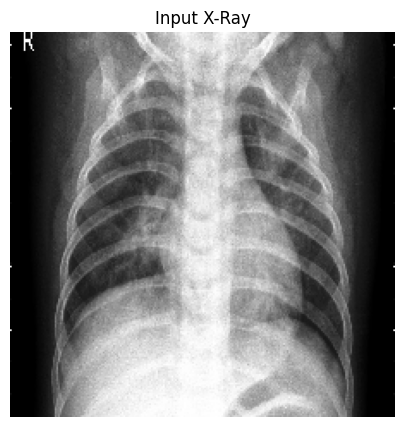


Prediction Probabilities:
----------------------------------------
Covid               : 17.71%
Normal              : 9.34%
Viral Pneumonia     : 72.95%

FINAL PREDICTION
Predicted Disease : Viral Pneumonia
Confidence Score  : 72.95%


In [5]:
# ==========================================
# STEP 14 : PREDICT NEW IMAGE (SEPARATE CELL)
# ==========================================

import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array
)

# Enter test image path
IMAGE_PATH = "TEPENU.jpeg"   # Change image name if needed

if not os.path.exists(IMAGE_PATH):
    print(f"Error: Image not found -> {IMAGE_PATH}")

else:

    # Load image
    img = load_img(
        IMAGE_PATH,
        target_size=(224, 224)
    )

    # Display image
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input X-Ray")
    plt.show()

    # Preprocess image
    img_array = img_to_array(img)

    img_array = img_array.astype("float32") / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Prediction
    pred = best_model.predict(
        img_array,
        verbose=0
    )

    # Class names
    classes = list(
        train_generator.class_indices.keys()
    )

    # Probabilities
    print("\nPrediction Probabilities:")
    print("-"*40)

    for i, cls in enumerate(classes):
        print(
            f"{cls:<20}: {pred[0][i]*100:.2f}%"
        )

    # Best prediction
    max_prob = np.max(pred)

    predicted_index = np.argmax(pred)

    disease = classes[predicted_index]

    confidence = max_prob * 100

    # Confidence threshold
    if confidence < 50:
        disease = "Uncertain"

    print("\n" + "="*40)
    print("FINAL PREDICTION")
    print("="*40)

    print(
        f"Predicted Disease : {disease}"
    )

    print(
        f"Confidence Score  : {confidence:.2f}%"
    )

In [4]:
# ==========================================================
# COMPLETE AI MEDICAL REPORT (SINGLE CELL)
# ==========================================================

# Install reportlab if not already installed
!pip install reportlab

import pandas as pd
import zipfile # Import zipfile module
import os # Import os module to check for file existence
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    PageBreak
)
from reportlab.lib.styles import getSampleStyleSheet

# ----------------------------------------------------------
# LOAD KAGGLE MEDICAL DATABASE
# ----------------------------------------------------------

# Define the path to the medical dataset zip file
medical_zip_path = "archive (4).zip"

# Check if the zip file exists before attempting to extract
if os.path.exists(medical_zip_path):
    # Extract the medical dataset zip file
    with zipfile.ZipFile(
        medical_zip_path,
        'r'
    ) as zip_ref:
        zip_ref.extractall("./medical_dataset")

    medical_df = pd.read_csv(
        "./medical_dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv" # Corrected path
    )

    symptom_columns = medical_df.columns[1:]

    # ----------------------------------------------------------
    # MAP X-RAY CLASSES TO DISEASE DATASET
    # ----------------------------------------------------------

    disease_mapping = {
        "Covid": "influenza",
        "COVID": "influenza",
        "Viral Pneumonia": "pneumonia",
        "Normal": None
    }

    mapped_disease = disease_mapping.get(
        disease,
        disease.lower()
    )

    # ----------------------------------------------------------
    # EXTRACT SYMPTOMS
    # ----------------------------------------------------------

    def get_symptoms(mapped_name):

        if mapped_name is None:
            return ["No symptoms detected (Healthy Condition)"]

        disease_rows = medical_df[
            medical_df['diseases'].astype(str).str.lower()
            == mapped_name.lower()
        ]

        if len(disease_rows) == 0:
            return ["No symptom information available"]

        first_row = disease_rows.iloc[0]

        symptoms = []

        for col in symptom_columns:

            try:
                if first_row[col] == 1:
                    symptoms.append(col)
            except:
                pass

        return symptoms[:20]

    symptoms = get_symptoms(mapped_disease)

    # ----------------------------------------------------------
    # SEVERITY
    # ----------------------------------------------------------

    if confidence >= 95:
        severity = "High"

    elif confidence >= 80:
        severity = "Moderate"

    else:
        severity = "Low"

    # ----------------------------------------------------------
    # RECOMMENDATIONS
    # ----------------------------------------------------------

    if disease.lower() == "covid":

        causes = "SARS-CoV-2 Viral Infection"

        tests = [
            "RT-PCR Test",
            "Rapid Antigen Test",
            "Chest CT Scan"
        ]

        treatments = [
            "Rest",
            "Hydration",
            "Antiviral Medication",
            "Medical Monitoring"
        ]

        prevention = [
            "Vaccination",
            "Mask Usage",
            "Hand Hygiene",
            "Social Distancing"
        ]

    elif disease.lower() == "viral pneumonia":

        causes = "Viral Infection Affecting Lungs"

        tests = [
            "Chest X-Ray",
            "Blood Test",
            "CT Scan"
        ]

        treatments = [
            "Antiviral Medication",
            "Oxygen Support",
            "Rest"
        ]

        prevention = [
            "Vaccination",
            "Healthy Lifestyle",
            "Avoid Smoking"
        ]

    else:

        causes = "Healthy Chest X-Ray"

        tests = [
            "Routine Health Checkup"
        ]

        treatments = [
            "No Treatment Required"
        ]

        prevention = [
            "Regular Exercise",
            "Balanced Diet",
            "Adequate Sleep"
        ]

    # ----------------------------------------------------------
    # PRINT REPORT
    # ----------------------------------------------------------

    print("\n")
    print("="*70)
    print("                AI GENERATED MEDICAL REPORT")
    print("="*70)

    print(f"\nPredicted Disease : {disease}")
    print(f"Confidence Score  : {confidence:.2f}%")
    print(f"Severity Level    : {severity}")

    print("\nPossible Cause:")
    print(causes)

    print("\nLikely Symptoms:")

    for symptom in symptoms:
        print("•", symptom)

    print("\nRecommended Tests:")

    for item in tests:
        print("•", item)

    print("\nSuggested Treatment:")

    for item in treatments:
        print("•", item)

    print("\nPrevention Tips:")

    for item in prevention:
        print("•", item)

    print("\nDoctor Recommendation:")
    print(
        "Consult a certified healthcare professional "
        "for proper diagnosis and treatment."
    )

    print("\nDISCLAIMER:")
    print(
        "This report is generated using Artificial "
        "Intelligence and should not be considered "
        "a final medical diagnosis."
    )

    print("="*70)

    # ----------------------------------------------------------
    # SAVE PDF REPORT
    # ----------------------------------------------------------

    pdf = SimpleDocTemplate(
        "AI_Medical_Report.pdf"
    )

    styles = getSampleStyleSheet()

    elements = []

    elements.append(
        Paragraph(
            "AI Generated Medical Report",
            styles['Title']
        )
    )

    elements.append(Spacer(1,12))

    elements.append(
        Paragraph(
            f"<b>Predicted Disease:</b> {disease}",
            styles['Normal']
        )
    )

    elements.append(
        Paragraph(
            f"<b>Confidence Score:</b> {confidence:.2f}%",
            styles['Normal']
        )
    )

    elements.append(
        Paragraph(
            f"<b>Severity Level:</b> {severity}",
            styles['Normal']
        )
    )

    elements.append(Spacer(1,12))

    elements.append(
        Paragraph(
            "<b>Possible Cause</b>",
            styles['Heading2']
        )
    )

    elements.append(
        Paragraph(
            causes,
            styles['Normal']
        )
    )

    elements.append(Spacer(1,12))

    elements.append(
        Paragraph(
            "<b>Likely Symptoms</b>",
            styles['Heading2']
        )
    )

    for symptom in symptoms:

        elements.append(
            Paragraph(
                symptom,
                styles['Normal']
            )
        )

    elements.append(Spacer(1,12))

    elements.append(
        Paragraph(
            "<b>Recommended Tests</b>",
            styles['Heading2']
        )
    )

    for item in tests:

        elements.append(
            Paragraph(
                item,
                styles['Normal']
            )
        )

    elements.append(Spacer(1,12))

    elements.append(
        Paragraph(
            "<b>Suggested Treatment</b>",
            styles['Heading2']
        )
    )

    for item in treatments:

        elements.append(
            Paragraph(
                item,
                styles['Normal']
            )
        )

    elements.append(Spacer(1,12))

    elements.append(
        Paragraph(
            "<b>Prevention Tips</b>",
            styles['Heading2']
        )
    )

    for item in prevention:

        elements.append(
            Paragraph(
                item,
                styles['Normal']
            )
        )

    elements.append(PageBreak())

    elements.append(
        Paragraph(
            "DISCLAIMER",
            styles['Heading1']
        )
    )

    elements.append(
        Paragraph(
            "This report is generated by an AI model "
            "and should only be used for educational "
            "and research purposes. Consult a medical "
            "professional before making healthcare "
            "decisions.",
            styles['Normal']
        )
    )

    pdf.build(elements)

    print("\nAI_Medical_Report.pdf saved successfully.")
else:
    print(f"Error: Required zip file not found at {medical_zip_path}. Please ensure 'archive (4).zip' is in the /content/ directory.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.5 MB/s eta 0:00:00


                AI GENERATED MEDICAL REPORT

Predicted Disease : Normal
Confidence Score  : 89.63%
Severity Level    : Moderate

Possible Cause:
Healthy Chest X-Ray

Likely Symptoms:
• No symptoms detected (Healthy Condition)

Recommended Tests:
• Routine Health Checkup

Suggested Treatment:
• No Treatment Required

Prevention Tips:
• Regular Exercise
• Balanced Diet
• Adequate Sleep

Doctor Recommendation:
Consult a certified healthcare professional for proper diagnosis and treatment.

DISCLAIMER:
This report is generated using Artificial Intelligence and should not be considered a final medical diagnosis.

AI_Medical_Report.pdf saved successfully.
